In [15]:
import sys
import os
import numpy as np
import pandas as pd
from scipy.spatial import distance_matrix
from typing import List
import matplotlib.pyplot as plt
import math
import time
sys.path.insert(1, '../utils')
from utils import *
from utils import plot_solution, greedy_2_regret_weighted, score, get_random_solution
from typing import Callable, Tuple
from abc import ABC, abstractmethod
from sortedcontainers import SortedList
import random
import numba

In [16]:
a=pd.read_csv('../data/TSPA.csv', sep=';', header=None)
b=pd.read_csv('../data/TSPB.csv', sep=';', header=None)
tspa=pd.DataFrame(data=a.values, columns=['x', 'y', 'val'])
tspb=pd.DataFrame(data=b.values, columns=['x', 'y', 'val'])
coordinates=tspa[['x', 'y']].values
coordinatesb=tspb[['x', 'y']].values
dist=distance_matrix(coordinates, coordinates)
dist=np.round(dist)
distb=distance_matrix(coordinatesb, coordinatesb)
distb=np.round(distb)
costs=tspa[['val']].values
costsb=tspb[['val']].values

In [17]:
class Neighborhood(ABC):
    @abstractmethod
    def neighborhood_size(self):
        pass

    @abstractmethod
    def get_difference(self, ind, solution: List[int], unselected):
        pass

    @abstractmethod
    def modify_solution(self, ind, solution: List[int], unselected):
        pass


In [18]:
class EdgeNeighborhood(Neighborhood):
    def __init__(self, distance_matrix: np.ndarray, costs: np.ndarray, n) -> None:
        self.distance_matrix = distance_matrix
        self.costs = costs
        self.indexes = list()
        for i in range(1, n-1):
            m = n - 1 if i == 1 else n
            for j in range(i+1, m):
                self.indexes.append((i,j))
        self.indexes=np.array(self.indexes)
        self.size=len(self.indexes)
    def neighborhood_size(self):
        return self.size
    def batch_get_differences(self, solution: List[int], unselected: SortedList, indexes=None):
        n = 100
        
        indexes = self.indexes
        i_vals, j_vals = indexes[:, 0], indexes[:, 1]
        s=np.array(solution)
        i1 = s[(i_vals - 1) % n]
        i2 = s[i_vals]
        j1 = s[j_vals]
        j2 = s[(j_vals + 1) % n]
        return -self.distance_matrix[i1, i2] - self.distance_matrix[j1, j2] \
            + self.distance_matrix[i1, j1] + self.distance_matrix[i2, j2]
    def get_difference(self, ind, solution: List[int], unselected: SortedList):
        n = 100
        i, j = self.indexes[ind]

        i1 = solution[i - 1]
        i2 = solution[i]

        j1 = solution[j]
        j2 = solution[(j + 1)%n]

        return -self.distance_matrix[i1, i2] - self.distance_matrix[j1, j2] \
            + self.distance_matrix[i1, j1] + self.distance_matrix[i2, j2]
    
    def modify_solution(self, ind, solution: List[int], unselected: SortedList):
        i, j = self.indexes[ind]
        solution[i:j+1] = solution[j:i-1:-1]
        return solution
    def get_affected_indexes(self, ind, solution: List[int]) -> List[int]:
        i, j = self.indexes[ind]
        start = i - 1
        end = j + 2
        reversed_segment = set(range(start, end)) 
        affected = set()
        for k, (x, y) in enumerate(self.indexes):
            if x in reversed_segment or y in reversed_segment:
                affected.add(k)

        return list(affected)

    
class InterNeighborhood(Neighborhood):
    def __init__(self, distance_matrix: np.ndarray, costs: np.ndarray, n) -> None:
        self.dist_mat = (distance_matrix+costs).T
        self.indexes = list()
        m = len(self.dist_mat) - n
        for i in range(n):
            for j in range(m):
                self.indexes.append((i,j))
        self.indexes=np.array(self.indexes)

        self.size=len(self.indexes)
    def neighborhood_size(self):
        return self.size
    def batch_get_differences(self, solution: List[int], unselected_list: List[int], indexes=None):
        if indexes is None:
            indexes = np.arange(len(self.indexes)) 
        n = 100
        selected_indexes = self.indexes[indexes]
        indices_i, indices_j = selected_indexes[:, 0], selected_indexes[:, 1]
        i_prev = (indices_i - 1) % n
        i_next = (indices_i + 1) % n
        s=np.array(solution)
        u=np.array(unselected_list)
        node_prev = s[i_prev]
        node_current =s[indices_i]  
        node_next = s[i_next]
        node_unselected = u[indices_j]
        differences = (
            -self.dist_mat[node_prev, node_current]
            - self.dist_mat[node_current, node_next]
            + self.dist_mat[node_prev, node_unselected]
            + self.dist_mat[node_unselected, node_next]
        )
        return differences
    def get_difference(self, ind, solution: List[int], unselected):
        n = len(solution)
        i, j = self.indexes[ind]
        i1 = solution[(i-1)%n]
        i2 = solution[i]
        i3 = solution[(i+1)%n]

        j1 = unselected[j]

        return -self.dist_mat[i1, i2] -self.dist_mat[i2, i3] + self.dist_mat[i1, j1] + self.dist_mat[j1, i3]
    
    def modify_solution(self, ind, solution: List[int], unselected: SortedList):
        i, j = self.indexes[ind]
        current_node = solution[i]
        solution[i] = unselected[j]
        unselected.remove(unselected[j])
        unselected.add(current_node)
        return solution
    def get_affected_indexes(self, ind, solution: List[int]) -> List[int]:
        i, j = self.indexes[ind]
        n = len(solution)
        adjacent_indices = { (i - 1) % n, (i + 1) % n, i }
        affected = set()
        for k, (x, y) in enumerate(self.indexes):
            if x in adjacent_indices or y in adjacent_indices:
                affected.add(k)
            if y == j:
                affected.add(k)
        
        return list(affected)

class CombinedNeighborhood(Neighborhood):
    def __init__(self , neighborhoods: List[Neighborhood]) -> None:
        self.neighborhoods = neighborhoods
     
        self.offsets = np.cumsum([0] + [n.neighborhood_size() for n in neighborhoods])
        self.size = self.offsets[-1]
        self.indexes = np.concatenate(
            [n.indexes for  n in neighborhoods]
        )
    def neighborhood_size(self):
        return self.size
    def batch_get_differences(self, solution: List[int], unselected: SortedList, indexes=None):
        if indexes is None:
            differences = []
            for neighborhood in self.neighborhoods:
                differences.append(neighborhood.batch_get_differences(solution, unselected))
            return np.concatenate(differences)
        else:
            differences = []
            idx=0
            
            id1=0
            for neighborhood in self.neighborhoods:
                idx+=neighborhood.size
                idxs=np.array(indexes)
                idxs=idxs[idxs>id1]
                idxs=idxs[idxs<idx] 
                idxs=idxs-id1
                differences.append(neighborhood.batch_get_differences(solution, unselected, idxs))
                id1+=idx
            return np.concatenate(differences)
    def get_difference(self, ind, solution: List[int], unselected):
        for neighborhood in self.neighborhoods:
            size = neighborhood.neighborhood_size()
            if ind < size:
                return neighborhood.get_difference(ind, solution, unselected)
            ind -= size

    def modify_solution(self, ind, solution: List[int], unselected: SortedList):
        for neighborhood in self.neighborhoods:
            size = neighborhood.neighborhood_size()
            if ind < size:
                return neighborhood.modify_solution(ind, solution, unselected)
            ind -= size
    def get_affected_indexes(self, ind, solution: List[int]) -> List[int]:
            size=self.neighborhoods[0].neighborhood_size()
            if ind < size:
                return self.neighborhoods[0].get_affected_indexes(ind, solution)
            else:
                ind-=size
                return [x+size for x in self.neighborhoods[1].get_affected_indexes(ind, solution)]
            

In [19]:

            

class SteepestLocalSearch:
    def __init__(self, starting_solution: List[int], distance_matrix: np.ndarray, costs: np.ndarray, neighborhood: 'Neighborhood'):
        self.solution = starting_solution.copy()
        self.distance_matrix = distance_matrix
        self.costs = costs
        self.neighborhood = neighborhood
        self.unselected = SortedList(range(len(costs)))
        for i in starting_solution:
            self.unselected.remove(i)
        self.LM = {} 

    def initialize_moves(self):
        deltas=self.neighborhood.batch_get_differences(self.solution, self.unselected)
        idx=np.where(deltas < 0)[0]
        for i in idx:

            self.LM[i] = deltas[i]

    def update_moves(self, affected_indexes: List[int]):
        deltas=self.neighborhood.batch_get_differences(self.solution, self.unselected)
    
        for idx in affected_indexes:
            if deltas[idx] < 0:
                self.LM[idx] = deltas[idx]
            elif idx in self.LM:
                del self.LM[idx]
    def find_best_move(self):
        best_move = None
        best_delta = float('inf')
        
        for idx, delta in self.LM.items():
            if delta >= best_delta:
                continue
                
            move = (idx, delta)
            app = self.is_move_applicable(move)
            if app == 1:
                best_delta = delta
                best_move = move
                
        return best_move
    def get_sorted_moves(self):
        return sorted(self.LM.items(), key=lambda x: x[1])

    def is_move_applicable(self, move: Tuple[int, float]) -> bool:
        ind, _ = move
        i, j = self.neighborhood.indexes[ind]
        current_edges = {(self.solution[k], self.solution[(k + 1) % len(self.solution)]) for k in range(len(self.solution))}
        move_edges = {(self.solution[i - 1], self.solution[i]), (self.solution[j], self.solution[(j + 1) % len(self.solution)])}
        reversed_edges = {(b, a) for (a, b) in move_edges}

    
        if move_edges.isdisjoint(current_edges) and reversed_edges.isdisjoint(current_edges):
            return 0 
        elif move_edges.issubset(reversed_edges):
            return 2  
        return 1  

    def apply_move(self, move: Tuple[int, float]) -> List[int]:
        ind, _ = move
        affected_indexes = self.neighborhood.get_affected_indexes(ind, self.solution)
        self.solution = self.neighborhood.modify_solution(ind, self.solution, self.unselected)
        return affected_indexes

    def steepest_search(self):
        self.initialize_moves()
        while True:
            best_move = self.find_best_move()
            if best_move is None:
                return self.solution
                
            affected_indexes = self.apply_move(best_move)
            del self.LM[best_move[0]]
            self.update_moves(affected_indexes) 

            

In [20]:
def steepest(starting_solution: List[int], distance_matrix: np.ndarray, costs: np.ndarray, neighborhood: Neighborhood) -> list:
    unselected = SortedList(range(len(costs)))
    for i in starting_solution:
        unselected.remove(i)

    solution = starting_solution.copy()

    while True:
        objective_changes = neighborhood.batch_get_differences(solution, unselected)
        best_index = np.argmin(objective_changes)
    
        if objective_changes[best_index] >= 0:
            return solution
    
        solution = neighborhood.modify_solution(best_index, solution, unselected)


In [21]:
def msls( distance_matrix, costs, neighborhood,selected_nodes, number_of_iterations=200):
   
    solutions=[]
    for x in range(number_of_iterations):
        np.random.shuffle(selected_nodes)
        solutions.append(selected_nodes[:100])
    solutions= [SteepestLocalSearch(x, dist, costs, neighborhood).steepest_search() for x in solutions]
    best_fit=999999999
    best_sol=None
    for sol in solutions:
        s=steepest(sol, dist, costs, neighborhood)
        if score(s, distance_matrix, costs) < best_fit:
            best_fit=score(s, distance_matrix, costs)
            best_sol=s
    return best_sol

In [22]:
def ils(pert_f, distance_matrix, costs, neighborhood, selected_nodes):
    np.random.shuffle(selected_nodes)
    x=selected_nodes[:100]
    x=SteepestLocalSearch(x, dist, costs, neighborhood).steepest_search()
    best_fit=999999999
    best_sol=None
    start_time=time.time()
    i=0
    previous_score=score(x, distance_matrix, costs)
    while time.time()-start_time<25:
        y=x.copy()
        for function in pert_f:
            function(y)
        
        y=steepest(y, dist, costs, neighborhood)
      
        scor=score(y, distance_matrix, costs)
        if scor<previous_score:
            x=y
        i+=1
        if  scor< best_fit:
            best_fit=scor
            best_sol=y
    return best_sol, i

In [23]:
def rswap(sol):
    i=np.random.randint(0,90)
    j=i+10

    tmp=sol[i]
    sol[i]=sol[j]
    sol[j]=tmp

def swich(sol):
    a=np.random.randint(0,100)
    node=sol[a]
    u=[x for x in range(200) if x not in sol]
    d=dist[node, u]
    m=np.argmin(d)
    sol[a]=u[m]
 
def shuff(sol):
    i=np.random.randint(0,90)
    j=i+10

    s=sol[i:j]
    np.random.shuffle(s)
    sol[i:j]=s
  
    
def invert(sol):
    i=np.random.randint(0,90)
    j=i+10
    sol[i:j]=sol[i:j][::-1]
    

In [1]:
# Version with weighted combination and distance threshold
def modified_hits_for_tsp_v2(distance_matrix, node_costs, 
                            distance_weight=0.5, cost_weight=0.5,
                            distance_threshold=None,
                            num_iterations=50, num_nodes=10):
    n = len(distance_matrix)
    
    # Create adjacency matrix based on distance threshold
    if distance_threshold:
        adjacency = ((distance_matrix+node_costs).T <= distance_threshold).astype(float)
    else:
        adjacency = np.ones((n, n))
        
    # Convert distances to similarities
    similarities = 1 / (distance_matrix + np.eye(n) * 1e-10)
    similarities *= adjacency  # Apply threshold mask
    
    # Normalize costs
    normalized_costs = 1 - (node_costs - np.min(node_costs)) / (np.max(node_costs) - np.min(node_costs))
    
    hub_scores = np.ones(n)
    auth_scores = np.ones(n)
    
    for _ in range(num_iterations):
        # Update scores with weighted combination
        auth_scores = distance_weight * (similarities.T @ hub_scores) + \
                     cost_weight * normalized_costs
        hub_scores = similarities @ auth_scores
        
        # Normalize
        auth_scores = auth_scores / np.max(auth_scores)
        hub_scores = hub_scores / np.max(hub_scores)
    
    final_scores = distance_weight * (hub_scores + auth_scores) + \
                  cost_weight * normalized_costs
    
    return np.argsort(final_scores)[0][-num_nodes:]

In [25]:
def modify_distances(distance_matrix, selected_nodes, large_value=9999999):
    """
    Modifies a distance matrix by setting distances to/from non-selected nodes to a large value.
    
    Parameters:
    distance_matrix : numpy.ndarray
        Square matrix containing distances between all nodes
    selected_nodes : list
        List of indices representing the selected nodes
    large_value : float, optional
        Value to replace distances for non-selected nodes (default: infinity)
    
    Returns:
    numpy.ndarray
        Modified distance matrix
    """
    # Create a copy to avoid modifying the original matrix
    modified_matrix = distance_matrix.copy()
    
    # Get the total number of nodes
    n_nodes = distance_matrix.shape[0]
    
    # Create a mask for non-selected nodes
    non_selected = list(set(range(n_nodes)) - set(selected_nodes))
    
    # Set distances to/from non-selected nodes to large_value
    for i in non_selected:
        modified_matrix[i, :] = large_value  # Set row to large_value
        modified_matrix[:, i] = large_value  # Set column to large_value
    
    # Keep original distances between selected nodes
    for i in selected_nodes:
        for j in selected_nodes:
            modified_matrix[i, j] = distance_matrix[i, j]
    for i in range(200):
        modified_matrix[i,i]=0
    return modified_matrix


In [26]:
def test_method(Neighborhood: CombinedNeighborhood, dists, cost, coordinate,selected_nodes, pert_f, name='',):
    scores_2=[]
    sols_2=[]
    times = list()
    i1=[]
    for x in range(3):
        begin_time = time.time()
        if len(pert_f)==0:
            solution_2=get_random_solution(200)
        else:
            solution_2, i=ils(pert_f, dists, cost, Neighborhood, selected_nodes)
            i1.append(i)
        times.append(time.time() - begin_time)

        solution_2 = [int(e) for e in solution_2]
        sols_2.append(solution_2)
        scores_2.append(score(solution_2, dists, cost))   
    print('scores: ', min(scores_2), sum(scores_2)/len(scores_2), max(scores_2))
    print(sols_2[scores_2.index(min(scores_2))])
    print(f'execution time: {min(times)} {sum(times)/len(times)} {max(times)}')
    if len(i1)>0:
        print(f'ils iterations: ', min(i1), sum(i1)/len(i1), max(i1))
    plot_solution(sols_2[scores_2.index(min(scores_2))], coordinate, cost, f'best solution for {name}')

In [27]:
selected_nodes=modified_hits_for_tsp_v2(dist, costs, distance_threshold=1200, num_nodes=110)
mod_dist=modify_distances(dist, selected_nodes)
n = 200
interNeighborhood = InterNeighborhood(mod_dist, costs, n // 2)
edgeNeighborhood = EdgeNeighborhood(mod_dist, costs, n // 2)
neighborhood = CombinedNeighborhood([edgeNeighborhood, interNeighborhood])

scores:  69095 69436.6 69787
[26, 100, 53, 180, 154, 135, 70, 127, 123, 162, 133, 151, 51, 118, 59, 65, 116, 43, 42, 184, 35, 84, 112, 4, 190, 10, 177, 54, 48, 160, 34, 181, 146, 22, 159, 193, 41, 139, 115, 46, 68, 69, 18, 108, 140, 93, 117, 0, 143, 183, 89, 186, 23, 137, 176, 80, 79, 63, 94, 124, 148, 9, 62, 102, 144, 14, 49, 178, 106, 52, 55, 57, 129, 92, 179, 185, 40, 119, 165, 90, 81, 196, 145, 78, 31, 56, 113, 175, 171, 16, 25, 44, 120, 2, 152, 97, 1, 101, 75, 86]
execution time: 25.83607840538025 26.046218001842497 26.300065994262695
ils iterations:  3581 3857.15 3895


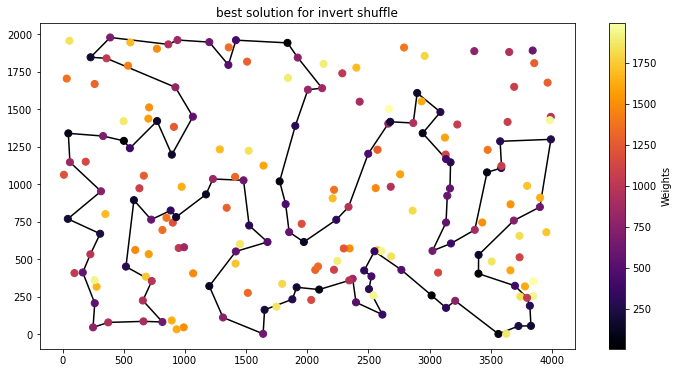

In [135]:
test_method(neighborhood, mod_dist, costs, coordinates, selected_nodes, pert_f=[invert,shuff], name='invert shuffle')

In [320]:
selected_nodes=modified_hits_for_tsp_v2(distb, costsb, distance_threshold=800, num_nodes=110)
mod_distb=modify_distances(distb, selected_nodes)
n = 200
interNeighborhood = InterNeighborhood(mod_distb, costsb, n // 2)
edgeNeighborhood = EdgeNeighborhood(mod_distb, costsb, n // 2)
neighborhood = CombinedNeighborhood([edgeNeighborhood, interNeighborhood])

scores:  43700 43845.333333333336 44013
[35, 109, 0, 29, 111, 82, 21, 8, 104, 144, 160, 33, 138, 11, 139, 168, 195, 13, 145, 15, 3, 70, 132, 169, 188, 6, 147, 51, 121, 90, 122, 133, 107, 40, 63, 135, 38, 27, 16, 1, 156, 198, 117, 193, 31, 54, 73, 136, 190, 80, 45, 142, 175, 78, 5, 177, 36, 61, 91, 141, 77, 81, 153, 187, 163, 89, 165, 127, 137, 114, 103, 113, 176, 194, 166, 86, 95, 130, 99, 185, 179, 66, 94, 47, 148, 60, 20, 28, 149, 4, 140, 183, 152, 34, 55, 18, 62, 124, 106, 143]
execution time: 26.11028504371643 26.137484550476074 26.16804075241089
ils iterations:  3680 3719.6666666666665 3765


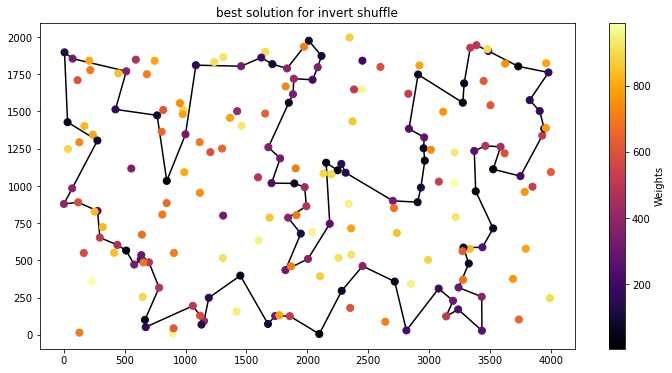

In [323]:
test_method(neighborhood, mod_distb, costsb, coordinatesb, selected_nodes, pert_f=[invert,shuff], name='invert shuffle')

scores:  43660 44010.1 44521
[190, 80, 45, 142, 175, 78, 5, 177, 36, 61, 91, 141, 77, 81, 153, 187, 163, 103, 89, 127, 137, 114, 113, 180, 176, 194, 166, 86, 185, 95, 130, 99, 22, 179, 66, 94, 47, 148, 60, 20, 28, 149, 4, 140, 183, 152, 34, 55, 18, 62, 124, 106, 143, 35, 109, 0, 29, 111, 82, 21, 8, 104, 144, 160, 33, 138, 11, 139, 168, 195, 13, 145, 15, 3, 70, 132, 169, 188, 6, 147, 51, 121, 90, 122, 133, 107, 40, 63, 135, 38, 27, 1, 156, 198, 117, 193, 31, 54, 73, 136]
execution time: 25.883069276809692 26.096460831165313 26.289060592651367
ils iterations:  3825 3876.8 3926


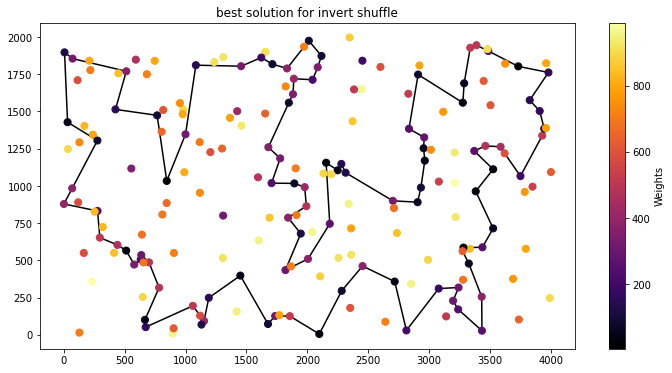

In [147]:
test_method(neighborhood, mod_distb, costsb, coordinatesb, selected_nodes, pert_f=[invert,shuff], name='invert shuffle')